# Assignment: Sentiment Analysis using NLP Pipeline & ML Models


## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import filedialpy as fp
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Namrata\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Namrata\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Load Dataset

In [3]:
# Use IMDb dataset
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 3. Data Understanding

In [15]:
print("Shape:", df.shape)

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

# Sample reviews
print("\nSample Data:")
print(df.sample(5))

Shape: (50000, 3)

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Data:
                                                  review sentiment  \
32017  During the early 1980's, Kurt Thomas was somet...  negative   
23590  A short review but...<br /><br />Avoid at all ...  negative   
41775  "The Devil in the Dark" is William Shatner's f...  positive   
20865  This unsung quiet gem tells the true story of ...  positive   
47899  Where to start. The film started out pretty we...  negative   

                                              clean_text  
32017  early kurt thomas something hero united state ...  
23590  short review butbr avoid cost thorough waste m...  
41775  devil dark william shatners favorite episode a...  
20865  unsung quiet gem tell true story pow escape pe...  
47899  start film started pretty well min mark caught...  


## 4. Preprocessing Function

In [16]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # Tokenization
    tokens = text.split()
    
    # Remove stopwords + Lemmatization
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(cleaned_tokens)


## 5. Apply Preprocessing

In [17]:
df['clean_text'] = df['review'].apply(preprocess_text)

df[['review', 'clean_text']].head()


,review,clean_text
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching episode youll ...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


## 6 Encode Labels

In [18]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

## 7. Train-Test Split

In [19]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# FEATURE ENGINEERING
## 8. Bag of Words

In [20]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)


## 9. TF-IDF

In [21]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


# MODEL BUILDING
## 10. Logistic Regression

In [22]:
lr = LogisticRegression()

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

## 11. Naive Bayes

In [23]:
nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

## 12. Decision Tree

In [24]:
dt = DecisionTreeClassifier()

dt.fit(X_train_tfidf, y_train)

y_pred_dt = dt.predict(X_test_tfidf)

# MODEL EVALUATION
## 13. Evaluation Function

In [25]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n🔹 {model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

## 14. Evaluate All Models

In [26]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_dt, "Decision Tree")


🔹 Logistic Regression
Accuracy: 0.8857
Precision: 0.8779588668994955
Recall: 0.8979956340543759
F1 Score: 0.8878642205435102

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


🔹 Naive Bayes
Accuracy: 0.8528
Precision: 0.8507374631268436
Recall: 0.8585036713633657
F1 Score: 0.8546029237455551

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


🔹 Decision Tree
Accuracy: 0.7161
Precision: 0.71956

## 15. Accuracy Comparison

In [27]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression    0.8857
1          Naive Bayes    0.8528
2        Decision Tree    0.7161


## 16. Plot Accuracy Graph 

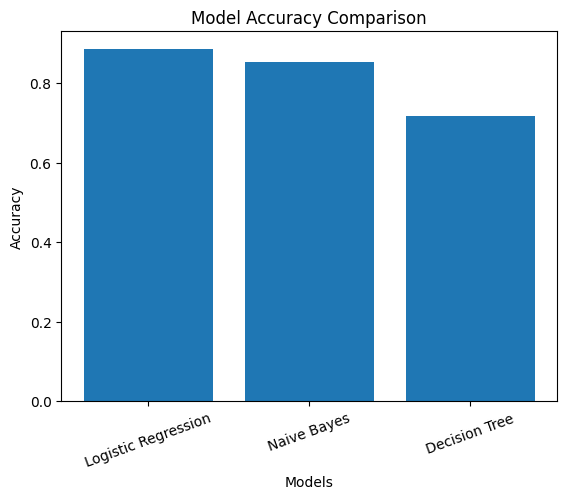

In [28]:
plt.figure()
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

## 17. Confusion Matrix

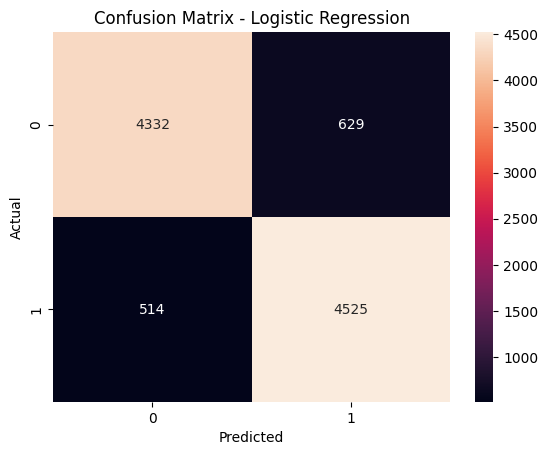

In [29]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# TEST CUSTOM INPUT
## 18. Prediction Function

In [30]:
def predict_sentiment(text):
    cleaned = preprocess_text(text)
    vector = tfidf.transform([cleaned])
    prediction = lr.predict(vector)
    
    return "Positive 😊" if prediction[0] == 1 else "Negative 😡"

## 19. Try Examples

In [31]:
print(predict_sentiment("This movie was amazing!"))
print(predict_sentiment("Worst experience ever"))

Positive 😊
Negative 😡


## 20. Final Insights
### 📊 Final Observations

- TF-IDF performed better than Bag of Words
- Logistic Regression achieved highest accuracy
- Preprocessing improved model performance significantly
- Decision Tree showed signs of overfitting

### 🏆 Conclusion

Building a complete NLP pipeline is essential for transforming raw text into meaningful insights. Proper preprocessing + feature engineering leads to better ML performance.